In [1]:
import tensorly as tl

tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


fmin=1
fmax = 14
sfreq = 128

paradigm = P300(resample=sfreq, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == meta['session'][0]
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 103)


/tmp/ipykernel_4065/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 52, 52)

In [6]:
from hoda.hoda import HODA
import warnings


hoda = HODA(
        rank=None,
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        delta=0.1,
        ortho=False,
        fit_forward=True
)



hoda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

HODA(delta=0.1, fit_forward=True, init='random', tol=1e-12, verbose=True)

In [7]:
import pandas as pd
df = pd.DataFrame(hoda.train_info_)
df

,iteration,mode,update,shrinkage,rank,objective
0,1,0,inf,0.000005,5,0.222433
1,1,1,inf,0.000120,12,0.403370
2,1,2,inf,0.000696,12,0.410477
3,2,0,inf,0.000127,4,0.164389
4,2,1,inf,0.000747,9,0.463065
...,...,...,...,...,...,...
763,255,1,5.426543e-10,0.001395,6,0.638442
764,255,2,4.986795e-10,0.001478,6,0.640030
765,256,0,4.330799e-11,0.000259,3,0.320605
766,256,1,5.118402e-10,0.001395,6,0.638441


<Axes: xlabel='iteration', ylabel='rank'>

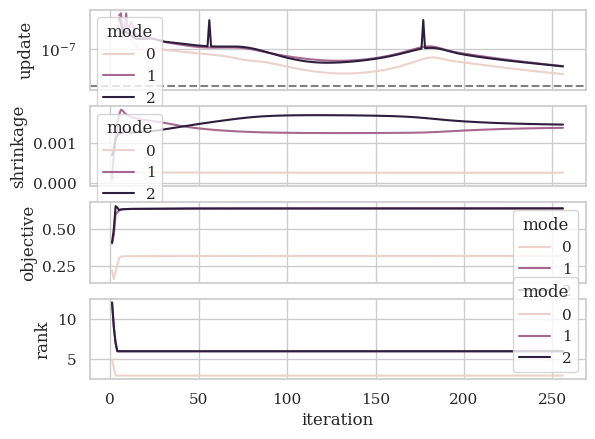

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])

In [9]:
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])



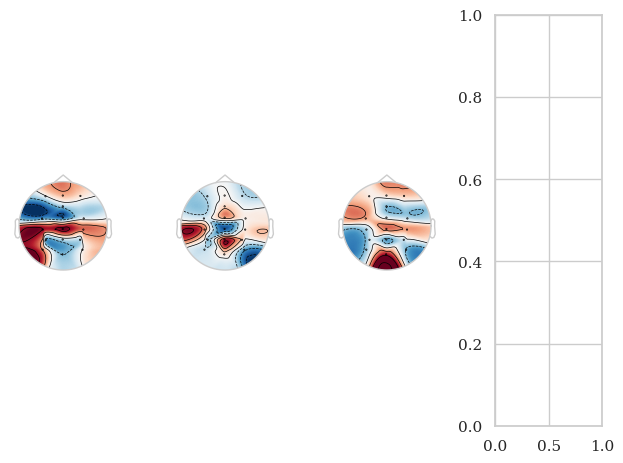

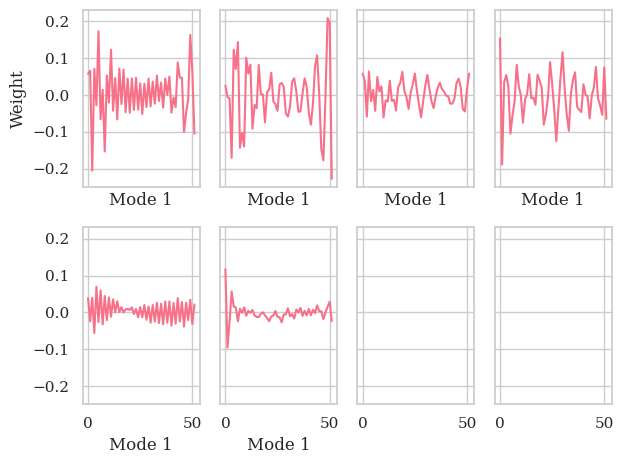

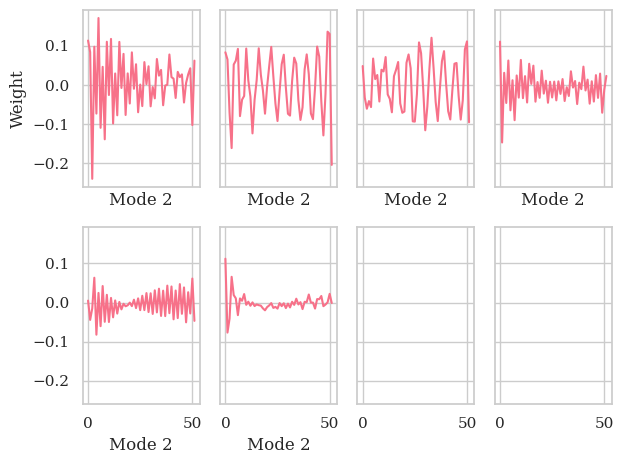

In [10]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');


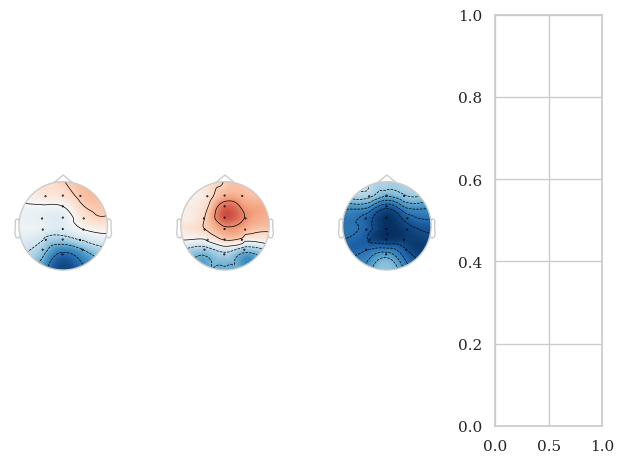

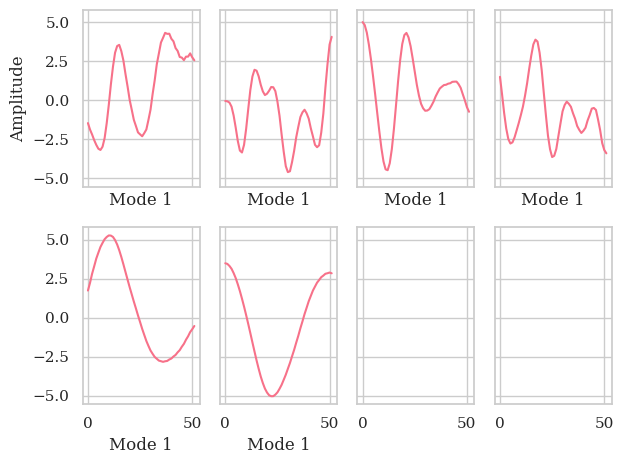

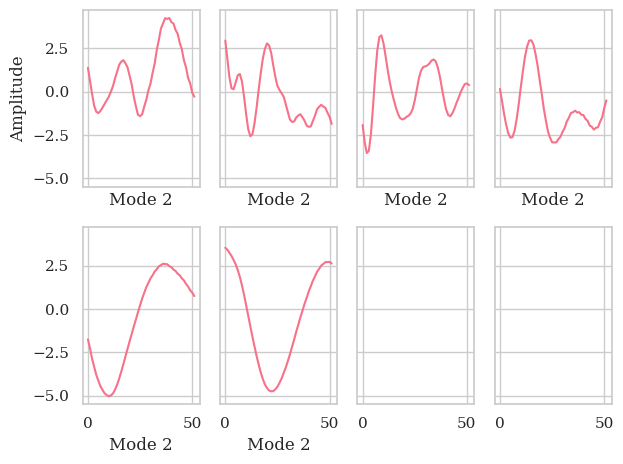

In [11]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');


In [12]:
Xt = hoda.transform(X)
Xt

array([[[[ 4.22533316e-09, -5.35099203e-10,  4.54579809e-09,
          -1.23345667e-09, -1.00914378e-08,  6.11554287e-09],
         [-5.16341089e-09, -5.88243924e-12,  6.71739648e-09,
           1.77713267e-10,  8.56514944e-09, -2.74696654e-09],
         [-1.94332785e-09, -6.13129462e-10, -1.40184943e-09,
          -1.73310138e-08, -6.80162098e-09,  1.49816627e-09],
         [-6.91150881e-09, -9.97737844e-09,  7.50541696e-09,
           1.41579817e-09,  6.68384533e-09, -4.86663088e-09],
         [ 1.46405265e-08, -2.96900830e-09, -4.17819756e-11,
          -1.05535428e-08,  2.94444776e-09, -2.09661717e-08],
         [ 4.82577892e-09, -4.45830913e-09, -2.80576336e-09,
          -5.65451533e-09,  2.14332641e-08,  1.12098973e-08]],

        [[ 8.12683956e-09, -1.18082329e-08,  6.96031410e-10,
          -3.74254548e-09,  6.25097634e-10,  6.32757196e-09],
         [-4.05285135e-09,  7.56774508e-09,  8.06858348e-09,
           1.19552461e-09,  1.37164320e-09, -6.33682655e-10],
         [ 2.2

<Axes: >

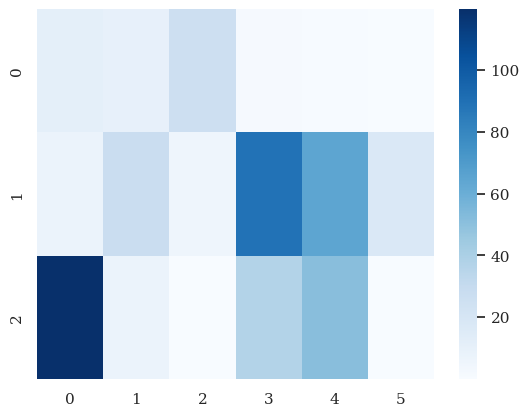

In [20]:
from hoda.util import f_multiway, f_oneway

import matplotlib
matplotlib.rcParams['axes.linewidth'] = 1
F, p = f_oneway(Xt,y)
sns.heatmap(tl.to_numpy(F[0]), cmap='Blues')

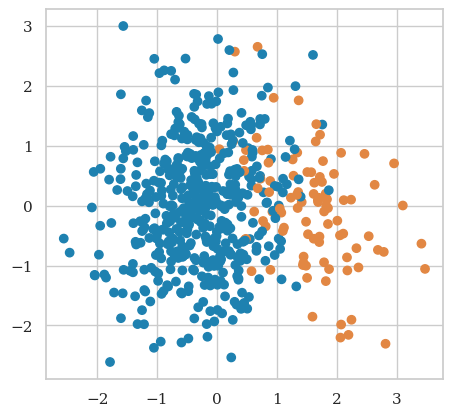

In [14]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')